<a href="https://colab.research.google.com/github/ayustha09/bus-delay-prediction/blob/main/london_arrival_bus_delay_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
gtfs_path = '/content/drive/MyDrive/Bus Delay Project/itm_london_gtfs.zip'
siri_path = '/content/drive/MyDrive/Bus Delay Project/sirivm_tfl_2025-06-17_015357 location.zip'


In [ ]:
import zipfile

with zipfile.ZipFile(gtfs_path, 'r') as zip_ref:
    zip_ref.extractall('/content/gtfs_data')

with zipfile.ZipFile(siri_path, 'r') as zip_ref:
    zip_ref.extractall('/content/siri_data')


In [ ]:
import pandas as pd

stops = pd.read_csv('/content/gtfs_data/stops.txt')
stop_times = pd.read_csv('/content/gtfs_data/stop_times.txt')
trips = pd.read_csv('/content/gtfs_data/trips.txt')
routes = pd.read_csv('/content/gtfs_data/routes.txt')

print("🛑 GTFS Stop Locations:")
display(stops.head())

print("📍 Stop Times:")
display(stop_times.head())

print("🚌 Trips:")
display(trips.head())

print("📓 Routes:")
display(routes.head())


🛑 GTFS Stop Locations:


/tmp/ipython-input-538267381.py:5: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  trips = pd.read_csv('/content/gtfs_data/trips.txt')


,stop_id,stop_code,stop_name,stop_lat,stop_lon,wheelchair_boarding,location_type,parent_station,platform_code
0,490014597S,48536,White Hart Ln Grt Cambridge Rd,51.60490,-0.085950,0,0,NaN,NaN
1,490007372S,74106,Granville Place,51.59650,-0.387280,0,0,NaN,NaN
2,490013521E,52358,The Ravensbury,51.39799,-0.157870,0,0,NaN,NaN
3,240G006160A,NaN,Bus Station,51.27127,0.193303,0,1,NaN,NaN
4,490007476V,56036,Palmers Green / Green Lanes,51.61252,-0.107100,0,0,NaN,NaN


📍 Stop Times:


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint
0,VJ000015b9797b7864ac37b8e5265301cfd1c79baf,21:43:00,21:43:00,490013259U,0,NaN,0,1,NaN,0
1,VJ000015b9797b7864ac37b8e5265301cfd1c79baf,21:43:29,21:43:29,490013777O,1,NaN,0,0,NaN,0
2,VJ000015b9797b7864ac37b8e5265301cfd1c79baf,21:44:12,21:44:12,490008399K,2,NaN,0,0,NaN,0
3,VJ000015b9797b7864ac37b8e5265301cfd1c79baf,21:45:00,21:45:00,490008392F,3,NaN,0,0,NaN,0
4,VJ000015b9797b7864ac37b8e5265301cfd1c79baf,21:45:45,21:45:45,490004327W2,4,NaN,0,0,NaN,0


🚌 Trips:


,route_id,service_id,trip_id,trip_headsign,direction_id,block_id,shape_id,wheelchair_accessible,vehicle_journey_code
0,58,28587,VJ0873eade6dfa11f222109beac2b7504007554ccd,"Belgravia, Victoria - Brighton",0,NaN,NaN,0,VJ109
1,58,28458,VJ0e8d68db7af2a97c5c5cdbe60be583a86843dc5c,"Belgravia, Victoria - Brighton",0,NaN,NaN,0,VJ70
2,58,28587,VJ01dbdf44f6d74ff8027d089fb3db5ae022559673,"Worthing - Victoria, London",1,NaN,NaN,0,VJ57
3,58,28587,VJ0b7453c953d79096488dd30c8d67da29644842ed,"Brighton - Victoria, London",1,NaN,NaN,0,VJ99
4,58,28586,VJ13f75a04ec4db779cd36001827762e1fc682ff51,"Belgravia, Victoria - Worthing",0,NaN,NaN,0,VJ47


📓 Routes:


,route_id,agency_id,route_short_name,route_long_name,route_type
0,58,OP5050,025,NaN,200
1,89,OP5050,444,NaN,200
2,100,OP5050,007,NaN,200
3,116,OP5050,022,NaN,200
4,289,OP53,372,NaN,3


In [ ]:
merged1 = pd.merge(stop_times, trips[['trip_id', 'route_id', 'trip_headsign']], on='trip_id', how='left')
merged_schedule = pd.merge(merged1, routes[['route_id', 'route_short_name']], on='route_id', how='left')

print("Merged GTFS Schedule:")
merged_schedule.head()


Merged GTFS Schedule:


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,route_id,trip_headsign,route_short_name
0,VJ000015b9797b7864ac37b8e5265301cfd1c79baf,21:43:00,21:43:00,490013259U,0,NaN,0,1,NaN,0,3348,NaN,E8
1,VJ000015b9797b7864ac37b8e5265301cfd1c79baf,21:43:29,21:43:29,490013777O,1,NaN,0,0,NaN,0,3348,NaN,E8
2,VJ000015b9797b7864ac37b8e5265301cfd1c79baf,21:44:12,21:44:12,490008399K,2,NaN,0,0,NaN,0,3348,NaN,E8
3,VJ000015b9797b7864ac37b8e5265301cfd1c79baf,21:45:00,21:45:00,490008392F,3,NaN,0,0,NaN,0,3348,NaN,E8
4,VJ000015b9797b7864ac37b8e5265301cfd1c79baf,21:45:45,21:45:45,490004327W2,4,NaN,0,0,NaN,0,3348,NaN,E8


In [ ]:
import xml.etree.ElementTree as ET

siri_file = '/content/siri_data/siri_tfl.xml'
tree = ET.parse(siri_file)
root = tree.getroot()

ns = {'siri': 'http://www.siri.org.uk/siri'}

records = []
activities = root.find('siri:ServiceDelivery', ns) \
                 .find('siri:VehicleMonitoringDelivery', ns) \
                 .findall('siri:VehicleActivity', ns)

for activity in activities:
    mvj = activity.find('siri:MonitoredVehicleJourney', ns)
    if mvj is not None:
        line_ref = mvj.findtext('siri:LineRef', default='N/A', namespaces=ns)
        vehicle_ref = mvj.findtext('siri:VehicleRef', default='N/A', namespaces=ns)
        aimed_departure = mvj.findtext('siri:OriginAimedDepartureTime', default='N/A', namespaces=ns)
        loc = mvj.find('siri:VehicleLocation', ns)
        if loc is not None:
            lat = loc.findtext('siri:Latitude', default='N/A', namespaces=ns)
            lon = loc.findtext('siri:Longitude', default='N/A', namespaces=ns)
        else:
            lat = lon = 'N/A'
        records.append({
            'line_ref': line_ref,
            'vehicle_id': vehicle_ref,
            'latitude': lat,
            'longitude': lon,
            'aimed_departure': aimed_departure
        })

siri_df = pd.DataFrame(records)

print("SIRI real-time data (sample):")
siri_df.head()


SIRI real-time data (sample):


,line_ref,vehicle_id,latitude,longitude,aimed_departure
0,236,LV23DJF,51.612316,-0.272919,2025-06-16T18:57:00+00:00
1,233,LV23DJJ,51.612433,-0.273591,2025-06-16T18:37:00+00:00
2,28,LK62DVF,51.533404,-0.247619,2025-06-17T23:48:00+00:00
3,463,LTZ1014,51.561789,-0.22232,2025-06-17T23:24:00+00:00
4,98,LK64ECN,51.561789,-0.221872,2025-06-17T23:05:00+00:00


Match Real-Time Bus to Nearest GTFS Stop

In [ ]:
import numpy as np
from math import radians, cos, sin, asin, sqrt

stops_df = pd.read_csv('/content/gtfs_data/stops.txt')[['stop_id', 'stop_name', 'stop_lat', 'stop_lon']]
print("✅ GTFS stop locations loaded")

stops_df['stop_lat'] = stops_df['stop_lat'].astype(float)
stops_df['stop_lon'] = stops_df['stop_lon'].astype(float)
siri_df['latitude'] = siri_df['latitude'].astype(float)
siri_df['longitude'] = siri_df['longitude'].astype(float)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

closest_stops = []

for _, row in siri_df.iterrows():
    bus_lat = row['latitude']
    bus_lon = row['longitude']

    stops_df['distance'] = stops_df.apply(
        lambda stop: haversine(bus_lat, bus_lon, stop['stop_lat'], stop['stop_lon']),
        axis=1
    )

    closest_stop = stops_df.loc[stops_df['distance'].idxmin()]

    closest_stops.append({
        'vehicle_id': row['vehicle_id'],
        'line_ref': row['line_ref'],
        'latitude': bus_lat,
        'longitude': bus_lon,
        'aimed_departure': row['aimed_departure'],
        'closest_stop_id': closest_stop['stop_id'],
        'closest_stop_name': closest_stop['stop_name'],
        'distance_to_stop_km': closest_stop['distance']
    })

matched_df = pd.DataFrame(closest_stops)

print("Closest stops matched:")
matched_df.head()


✅ GTFS stop locations loaded
Closest stops matched:


,vehicle_id,line_ref,latitude,longitude,aimed_departure,closest_stop_id,closest_stop_name,distance_to_stop_km
0,LV23DJF,236,51.612316,-0.272919,2025-06-16T18:57:00+00:00,490000070F,Edgware Station,0.099345
1,LV23DJJ,233,51.612433,-0.273591,2025-06-16T18:37:00+00:00,490000070F,Edgware Station,0.051988
2,LK62DVF,28,51.533404,-0.247619,2025-06-17T23:48:00+00:00,490003079R,Acton Lane Harlesden,0.116318
3,LTZ1014,463,51.561789,-0.222320,2025-06-17T23:24:00+00:00,490015033S,Cricklewood Bus Garage,0.099976
4,LK64ECN,98,51.561789,-0.221872,2025-06-17T23:05:00+00:00,490015033S,Cricklewood Bus Garage,0.073112


In [ ]:
threshold_km = 0.15

matched_df['status'] = matched_df['distance_to_stop_km'].apply(
    lambda d: 'on_time' if d <= threshold_km else 'late'
)
matched_df.head()


,vehicle_id,line_ref,latitude,longitude,aimed_departure,closest_stop_id,closest_stop_name,distance_to_stop_km,status
0,LV23DJF,236,51.612316,-0.272919,2025-06-16T18:57:00+00:00,490000070F,Edgware Station,0.099345,on_time
1,LV23DJJ,233,51.612433,-0.273591,2025-06-16T18:37:00+00:00,490000070F,Edgware Station,0.051988,on_time
2,LK62DVF,28,51.533404,-0.247619,2025-06-17T23:48:00+00:00,490003079R,Acton Lane Harlesden,0.116318,on_time
3,LTZ1014,463,51.561789,-0.222320,2025-06-17T23:24:00+00:00,490015033S,Cricklewood Bus Garage,0.099976,on_time
4,LK64ECN,98,51.561789,-0.221872,2025-06-17T23:05:00+00:00,490015033S,Cricklewood Bus Garage,0.073112,on_time


Exploratory Data Analysis

In [ ]:
print("Dataset shape:", matched_df.shape)
print("\n Missing values per column:")
print(matched_df.isnull().sum())


Dataset shape: (7723, 9)

 Missing values per column:
vehicle_id             0
line_ref               0
latitude               0
longitude              0
aimed_departure        0
closest_stop_id        0
closest_stop_name      0
distance_to_stop_km    0
status                 0
dtype: int64


In [ ]:
matched_df.describe()


,latitude,longitude,distance_to_stop_km
count,7723.000000,7723.000000,7723.000000
mean,51.505782,-0.116542,0.080853
std,0.076184,0.156255,0.135817
min,51.240609,-0.588826,0.000355
25%,51.462502,-0.221648,0.021470
50%,51.506788,-0.110823,0.043715
75%,51.561671,-0.018133,0.092827
max,51.721496,0.299068,1.655980


Delay Class Counts:
status
on_time    6761
late        962
Name: count, dtype: int64


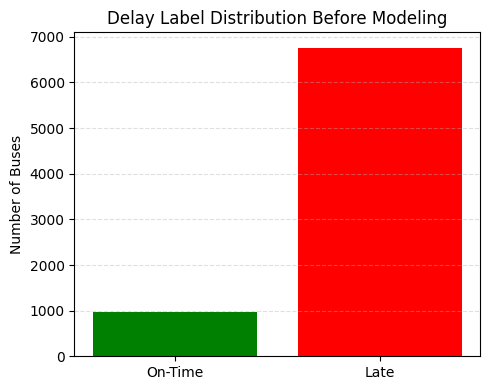

In [ ]:
print("Delay Class Counts:")
print(matched_df['status'].value_counts())

import matplotlib.pyplot as plt

labels = ['On-Time', 'Late']
counts = matched_df['status'].value_counts().sort_index()
colors = ['green', 'red']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts, color=colors)
plt.title("Delay Label Distribution Before Modeling")
plt.ylabel("Number of Buses")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

features = matched_df[['line_ref', 'latitude', 'longitude', 'distance_to_stop_km']]
target = matched_df['status']

le = LabelEncoder()
features['line_ref_encoded'] = le.fit_transform(features['line_ref'])

X = features.drop(columns=['line_ref'])
y = target.map({'on_time': 0, 'late': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Features prepared for ML model:")
X_train.head()


Features prepared for ML model:


/tmp/ipython-input-968654803.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['line_ref_encoded'] = le.fit_transform(features['line_ref'])


,latitude,longitude,distance_to_stop_km,line_ref_encoded
4290,51.429642,-0.103659,0.015528,479
1210,51.372520,-0.272695,0.158340,548
1940,51.571564,-0.421133,0.027560,598
6203,51.474398,-0.124033,0.096811,350
7450,51.560364,0.147996,0.034882,3


In [ ]:
# ============================================
# Logistic Regression Classification
# ============================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Create and train Logistic Regression model
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

# Make predictions
logreg_preds = logreg_model.predict(X_test)

# Evaluate model performance
logreg_acc = accuracy_score(y_test, logreg_preds)
print(f"Logistic Regression Accuracy: {logreg_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, logreg_preds))


Logistic Regression Accuracy: 0.9663

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1341
           1       1.00      0.75      0.85       204

    accuracy                           0.97      1545
   macro avg       0.98      0.87      0.92      1545
weighted avg       0.97      0.97      0.96      1545



In [ ]:
# ============================================
# Random Forest Classification
# ============================================
from sklearn.ensemble import RandomForestClassifier

# Create and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_preds = rf_model.predict(X_test)

# Evaluate model performance
rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))


Random Forest Accuracy: 0.9994

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1341
           1       1.00      1.00      1.00       204

    accuracy                           1.00      1545
   macro avg       1.00      1.00      1.00      1545
weighted avg       1.00      1.00      1.00      1545



In [ ]:
# ============================================
# XGBoost Classification
# ============================================
from xgboost import XGBClassifier

# Create and train XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_preds = xgb_model.predict(X_test)

# Evaluate model performance
xgb_acc = accuracy_score(y_test, xgb_preds)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds))


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [04:12:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9974

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1341
           1       1.00      0.99      0.99       204

    accuracy                           1.00      1545
   macro avg       1.00      0.99      0.99      1545
weighted avg       1.00      1.00      1.00      1545



In [ ]:
# Install LightGBM (one-time; safe to re-run)
!pip install -q lightgbm==4.5.0


In [ ]:
# ============================================
# LightGBM Classification
# ============================================
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

# Create and train LightGBM model
lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,           # no explicit depth limit
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
lgbm_model.fit(X_train, y_train)

# Make predictions
lgbm_preds = lgbm_model.predict(X_test)

# Evaluate model performance (matching your style)
lgbm_acc = accuracy_score(y_test, lgbm_preds)
print(f"LightGBM Accuracy: {lgbm_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lgbm_preds))


[LightGBM] [Info] Number of positive: 758, number of negative: 5420
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040320 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1018
[LightGBM] [Info] Number of data points in the train set: 6178, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [ ]:
# ============================================
# SVM Classification (RBF kernel) — NEW CELL
# Place this after your LightGBM cell
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    roc_auc_score, classification_report
)

# SVM in a pipeline with scaling; class_weight='balanced' helps with imbalance
svm_clf = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),  # safe for dense/sparse; doesn't alter your stored X
    ("svc", SVC(kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight="balanced",
                probability=True,   # enables predict_proba for ROC AUC later
                random_state=42))
])

# Train
svm_clf.fit(X_train, y_train)

# Predict labels and probabilities
svm_preds = svm_clf.predict(X_test)
svm_proba = svm_clf.predict_proba(X_test)[:, 1]

# Reports to match your existing style, plus a few robust metrics
print("SVM (RBF) Classification Results")
print(f"Accuracy:           {accuracy_score(y_test, svm_preds):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_test, svm_preds):.4f}")
print(f"MCC:                {matthews_corrcoef(y_test, svm_preds):.4f}")
print(f"ROC AUC:            {roc_auc_score(y_test, svm_proba):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, svm_preds))


SVM (RBF) Classification Results
Accuracy:           0.1320
Balanced Accuracy:  0.5000
MCC:                0.0000
ROC AUC:            0.9993

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1341
           1       0.13      1.00      0.23       204

    accuracy                           0.13      1545
   macro avg       0.07      0.50      0.12      1545
weighted avg       0.02      0.13      0.03      1545



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ============================================
# SVM (RBF) — Grid Search WITHOUT parallel workers (n_jobs=1)
# Fixes BrokenProcessPool / NumPy pickling issues in Colab
# ============================================

import numpy as np
from scipy import sparse
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    roc_auc_score, classification_report
)

# Detect whether your X matrices are sparse or dense to configure scaling properly
use_with_mean = False if sparse.issparse(X_train) else True

svm_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=use_with_mean)),
    ("svc", SVC(kernel="rbf", probability=True, random_state=42))
])

# Keep a compact but effective grid; balanced_accuracy is robust for imbalance
param_grid = {
    "svc__C": [0.1, 1, 5, 10, 50],
    "svc__gamma": ["scale", 0.01, 0.1, 1.0],
    "svc__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

svm_search_serial = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=1,            # <- single-process to avoid pickling issues
    verbose=0,
    refit=True
)

svm_search_serial.fit(X_train, y_train)

print("Best params:", svm_search_serial.best_params_)
print("Best CV balanced accuracy:", f"{svm_search_serial.best_score_:.4f}")

# Evaluate on test set
svm_best = svm_search_serial.best_estimator_
svm_best_preds = svm_best.predict(X_test)
svm_best_proba = svm_best.predict_proba(X_test)[:, 1]

print("\nSVM (RBF) — Tuned (serial) — Test Metrics")
print(f"Accuracy:           {accuracy_score(y_test, svm_best_preds):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_test, svm_best_preds):.4f}")
print(f"MCC:                {matthews_corrcoef(y_test, svm_best_preds):.4f}")
print(f"ROC AUC:            {roc_auc_score(y_test, svm_best_proba):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, svm_best_preds))


Best params: {'svc__C': 50, 'svc__class_weight': 'balanced', 'svc__gamma': 0.1}
Best CV balanced accuracy: 0.9960

SVM (RBF) — Tuned (serial) — Test Metrics
Accuracy:           0.9987
Balanced Accuracy:  0.9993
MCC:                0.9944
ROC AUC:            1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1341
           1       0.99      1.00      1.00       204

    accuracy                           1.00      1545
   macro avg       1.00      1.00      1.00      1545
weighted avg       1.00      1.00      1.00      1545



In [ ]:
# ============================================
# MLP (Neural Network) Classification — FIXED
# ============================================

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    roc_auc_score, classification_report
)

# Build MLP in a pipeline with scaling
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate="adaptive",
        max_iter=300,
        early_stopping=True,
        n_iter_no_change=15,
        random_state=42
    ))
])

# Train without sample weights
mlp_pipe.fit(X_train, y_train)

# Predictions
mlp_preds = mlp_pipe.predict(X_test)
mlp_proba = mlp_pipe.predict_proba(X_test)[:, 1]

# Evaluation
print("MLP (Neural Net) Classification Results")
print(f"Accuracy:           {accuracy_score(y_test, mlp_preds):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_test, mlp_preds):.4f}")
print(f"MCC:                {matthews_corrcoef(y_test, mlp_preds):.4f}")
print(f"ROC AUC:            {roc_auc_score(y_test, mlp_proba):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, mlp_preds))


MLP (Neural Net) Classification Results
Accuracy:           0.9974
Balanced Accuracy:  0.9923
MCC:                0.9887
ROC AUC:            1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1341
           1       1.00      0.99      0.99       204

    accuracy                           1.00      1545
   macro avg       1.00      0.99      0.99      1545
weighted avg       1.00      1.00      1.00      1545



Hyperparameter Tuning for XGBoost

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters found:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

xgb_best = grid_search.best_estimator_
y_pred_best = xgb_best.predict(X_test)
print("Test Accuracy with Tuned XGBoost:", accuracy_score(y_test, y_pred_best))


Fitting 3 folds for each of 54 candidates, totalling 162 fits


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [04:14:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best Cross-Validation Accuracy: 0.9990287332745497
Test Accuracy with Tuned XGBoost: 0.997411003236246


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [04:14:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [04:14:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [04:14:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [04:14:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [04:14:17] WARNING: /w

Cross-Validation Scores: [1.         0.997411   0.9961165  1.         0.99870466]
Mean CV Accuracy: 0.9984464342606101


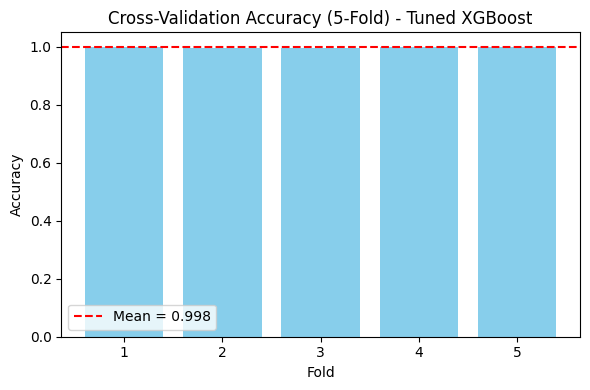

In [ ]:
#Cross-Validation
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

#5-fold
cv_scores = cross_val_score(xgb_best, X, y, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

plt.figure(figsize=(6,4))
plt.bar(range(1, 6), cv_scores, color='skyblue')
plt.axhline(np.mean(cv_scores), color='red', linestyle='--', label=f'Mean = {np.mean(cv_scores):.3f}')
plt.title('Cross-Validation Accuracy (5-Fold) - Tuned XGBoost')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# Build REAL comparison table from the models you already trained
# ============================================
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, matthews_corrcoef, roc_auc_score
)

def _pick_existing(candidates):
    """Return the first existing object from a list of variable names.
       If it's a GridSearchCV-like object, return its best_estimator_."""
    for name in candidates:
        if name in globals():
            obj = globals()[name]
            if hasattr(obj, "best_estimator_"):  # e.g., GridSearchCV
                return obj.best_estimator_
            return obj
    return None

def _positive_scores(model, X):
    """Return positive-class scores for ROC AUC (proba or decision_function)."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        # scale scores to 0..1 so ROC AUC works consistently
        from sklearn.preprocessing import MinMaxScaler
        return MinMaxScaler().fit_transform(s.reshape(-1, 1)).ravel()
    return None

# Map display name -> possible variable names YOU used
model_vars = {
    "Logistic Regression": ["logreg_model", "log_model", "lr_model"],
    "Random Forest":       ["rf_model", "random_forest_model"],
    "XGBoost (Tuned)":     ["xgb_best", "xgb_tuned"],
    "XGBoost (Default)":   ["xgb_model", "xgb_clf"],
    "LightGBM":            ["lgbm_model", "lgb_model"],
    "SVM (RBF)":           ["svm_best", "svm_clf", "svm_model"],
    "MLP (Neural Net)":    ["mlp_pipe", "mlp_model"]
}

rows, missing = [], []

for label, candidates in model_vars.items():
    model = _pick_existing(candidates)
    if model is None:
        missing.append(label)
        continue

    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    mcc  = matthews_corrcoef(y_test, y_pred)

    scores = _positive_scores(model, X_test)
    roc = roc_auc_score(y_test, scores) if scores is not None else np.nan

    rows.append({
        "Model": label,
        "Accuracy": round(acc, 4),
        "Balanced_Accuracy": round(bacc, 4),
        "MCC": round(mcc, 4),
        "ROC_AUC": (round(roc, 4) if not np.isnan(roc) else np.nan)
    })

# Create DataFrame, sort by robust metrics first
results_df = (
    pd.DataFrame(rows)
      .sort_values(by=["Balanced_Accuracy", "MCC", "Accuracy"], ascending=False)
      .reset_index(drop=True)
)

print("Classification Model Comparison (real results):")
display(results_df)

# Save for your report/appendix
results_df.to_csv("classification_model_comparison.csv", index=False)
print("\nSaved to: classification_model_comparison.csv")

# Let you know if something was not found (e.g., you didn't run a model cell yet)
if missing:
    print("\n(Info) Models not found and skipped:", ", ".join(missing))


Classification Model Comparison (real results):


,Model,Accuracy,Balanced_Accuracy,MCC,ROC_AUC
0,SVM (RBF),0.9987,0.9993,0.9944,1.0000
1,Random Forest,0.9994,0.9975,0.9972,1.0000
2,LightGBM,0.9987,0.9951,0.9943,1.0000
3,XGBoost (Tuned),0.9974,0.9923,0.9887,1.0000
4,XGBoost (Default),0.9974,0.9923,0.9887,1.0000
5,MLP (Neural Net),0.9974,0.9923,0.9887,1.0000
6,Logistic Regression,0.9663,0.8725,0.8469,0.9999



Saved to: classification_model_comparison.csv


In [ ]:
# ============================================
# Baseline model: DummyClassifier (sanity check)
# ============================================
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    precision_score, recall_score, f1_score, roc_auc_score
)
import numpy as np
import pandas as pd

# 1) Fit a simple baseline that always predicts the most frequent class
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(X_train, y_train)

# 2) Evaluate with the SAME metrics as other models
y_pred = dummy_clf.predict(X_test)

acc   = accuracy_score(y_test, y_pred)
bacc  = balanced_accuracy_score(y_test, y_pred)
mcc   = matthews_corrcoef(y_test, y_pred)
prec  = precision_score(y_test, y_pred, zero_division=0)
rec   = recall_score(y_test, y_pred, zero_division=0)
f1    = f1_score(y_test, y_pred, zero_division=0)

# For ROC AUC, use predict_proba if available; DummyClassifier provides it
y_score = dummy_clf.predict_proba(X_test)[:, 1]
roc    = roc_auc_score(y_test, y_score)

print("DummyClassifier (most_frequent) — Baseline Metrics")
print(f"Accuracy:           {acc:.4f}")
print(f"Balanced Accuracy:  {bacc:.4f}")
print(f"MCC:                {mcc:.4f}")
print(f"Precision:          {prec:.4f}")
print(f"Recall:             {rec:.4f}")
print(f"F1-Score:           {f1:.4f}")
print(f"ROC AUC:            {roc:.4f}")

# 3) (Optional) Add to your existing models_dict for later tables
#     This will NOT change any previous results; it only lets you include the baseline in comparisons
if 'models_dict' in globals():
    models_dict["Baseline (Dummy)"] = dummy_clf

# 4) (Optional) Rebuild the full comparison table INCLUDING the baseline
#     If you already have build_metrics_df from earlier, this will use it; otherwise we rebuild quickly here.
def _rebuild_metrics_df(md, X, y):
    rows = []
    for name, model in md.items():
        yp = model.predict(X)
        a    = accuracy_score(y, yp)
        ba   = balanced_accuracy_score(y, yp)
        m    = matthews_corrcoef(y, yp)
        p    = precision_score(y, yp, zero_division=0)
        r    = recall_score(y, yp, zero_division=0)
        f    = f1_score(y, yp, zero_division=0)
        ys   = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X)
        ra   = roc_auc_score(y, ys)
        comp = (a + ba + m + p + r + f + ra) / 7.0
        rows.append({
            "Model": name,
            "Accuracy": a,
            "Balanced Accuracy": ba,
            "MCC": m,
            "Precision": p,
            "Recall": r,
            "F1-Score": f,
            "ROC AUC": ra,
            "Composite Score": comp
        })
    df = pd.DataFrame(rows).sort_values("Composite Score", ascending=False).reset_index(drop=True)
    return df

if 'models_dict' in globals():
    metrics_df_with_baseline = _rebuild_metrics_df(models_dict, X_test, y_test)
    # Round for display
    md_round = metrics_df_with_baseline.copy()
    md_round.iloc[:, 1:] = np.round(md_round.iloc[:, 1:], 4)
    print("\nUpdated comparison (including Dummy baseline):")
    display(md_round)
    # Save for the report appendix
    md_round.to_csv("classification_metrics_with_baseline.csv", index=False)


DummyClassifier (most_frequent) — Baseline Metrics
Accuracy:           0.8680
Balanced Accuracy:  0.5000
MCC:                0.0000
Precision:          0.0000
Recall:             0.0000
F1-Score:           0.0000
ROC AUC:            0.5000


In [ ]:
# ============================================
# Composite Performance Score & Ranking
# ============================================

from sklearn.metrics import precision_score, recall_score, f1_score

# Prepare a list to store results
model_metrics = []

# Loop through each trained model
for name, model in models_dict.items():
    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    mcc_val = matthews_corrcoef(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # ROC AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    roc_auc_val = roc_auc_score(y_test, y_score)

    # Composite Score (equal weights for all metrics)
    composite = (acc + bal_acc + mcc_val + precision + recall + f1 + roc_auc_val) / 7

    # Append results
    model_metrics.append([name, acc, bal_acc, mcc_val, precision, recall, f1, roc_auc_val, composite])

# Create DataFrame
import pandas as pd
metrics_df = pd.DataFrame(model_metrics, columns=[
    "Model", "Accuracy", "Balanced Accuracy", "MCC", "Precision", "Recall", "F1-Score", "ROC AUC", "Composite Score"
])

# Sort by Composite Score
metrics_df = metrics_df.sort_values(by="Composite Score", ascending=False).reset_index(drop=True)

# Display nicely
import numpy as np
metrics_df_rounded = metrics_df.copy()
metrics_df_rounded.iloc[:, 1:] = np.round(metrics_df_rounded.iloc[:, 1:], 4)

metrics_df_rounded


,Model,Accuracy,Balanced Accuracy,MCC,Precision,Recall,F1-Score,ROC AUC,Composite Score
0,Random Forest,0.9994,0.9975,0.9972,1.0000,0.9951,0.9975,1.0000,0.9981
1,SVM (RBF),0.9987,0.9993,0.9944,0.9903,1.0000,0.9951,1.0000,0.9968
2,LightGBM,0.9987,0.9951,0.9943,1.0000,0.9902,0.9951,1.0000,0.9962
3,MLP (Neural Net),0.9974,0.9923,0.9887,0.9950,0.9853,0.9901,1.0000,0.9927
4,XGBoost (Tuned),0.9974,0.9923,0.9887,0.9950,0.9853,0.9901,1.0000,0.9927
5,Logistic Regression,0.9663,0.8725,0.8469,1.0000,0.7451,0.8539,0.9999,0.8978
6,Baseline (Dummy),0.8680,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.2669



Saved to: classification_metrics_composite.csv


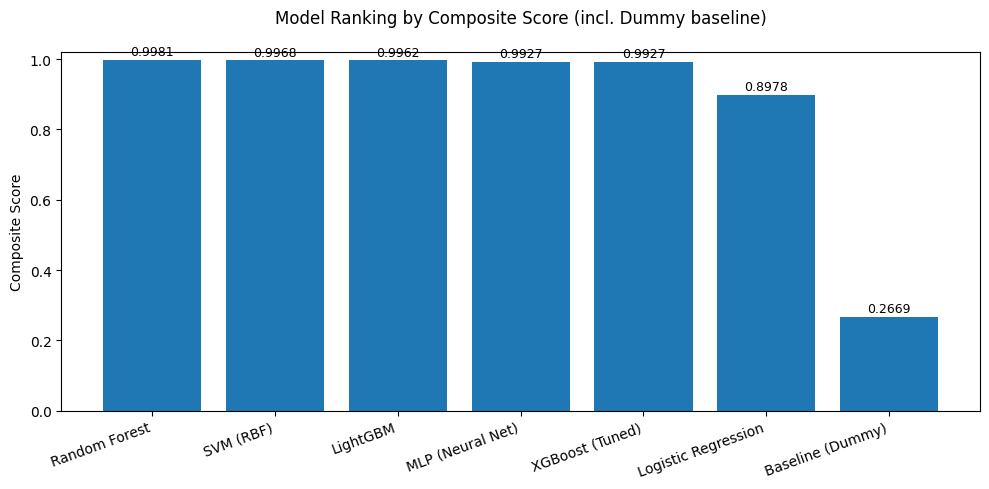

In [ ]:
# ============================================
# Bar chart: Composite Score (includes Dummy baseline)
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    precision_score, recall_score, f1_score, roc_auc_score
)

def build_metrics_df(md, X, y):
    rows = []
    for name, model in md.items():
        y_pred = model.predict(X)

        acc  = accuracy_score(y, y_pred)
        bacc = balanced_accuracy_score(y, y_pred)
        mcc  = matthews_corrcoef(y, y_pred)
        prec = precision_score(y, y_pred, zero_division=0)
        rec  = recall_score(y, y_pred, zero_division=0)
        f1   = f1_score(y, y_pred, zero_division=0)

        y_score = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X)
        roc  = roc_auc_score(y, y_score)

        composite = (acc + bacc + mcc + prec + rec + f1 + roc) / 7.0
        rows.append({
            "Model": name,
            "Accuracy": acc, "Balanced Accuracy": bacc, "MCC": mcc,
            "Precision": prec, "Recall": rec, "F1-Score": f1,
            "ROC AUC": roc, "Composite Score": composite
        })
    return pd.DataFrame(rows).sort_values("Composite Score", ascending=False).reset_index(drop=True)

# Recompute to guarantee baseline is included
metrics_df_with_baseline = build_metrics_df(models_dict, X_test, y_test)

# Plot
plt.figure(figsize=(10, 5))
x = np.arange(len(metrics_df_with_baseline))
scores = metrics_df_with_baseline["Composite Score"].values
labels = metrics_df_with_baseline["Model"].values

bars = plt.bar(x, scores)
plt.xticks(x, labels, rotation=20, ha="right")
plt.ylabel("Composite Score")
plt.title("Model Ranking by Composite Score (incl. Dummy baseline)\n")
plt.ylim(0.0, 1.02)
for rect, val in zip(bars, scores):
    plt.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.005,
             f"{val:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("composite_scores_with_baseline.png", dpi=300, bbox_inches="tight")
plt.show()


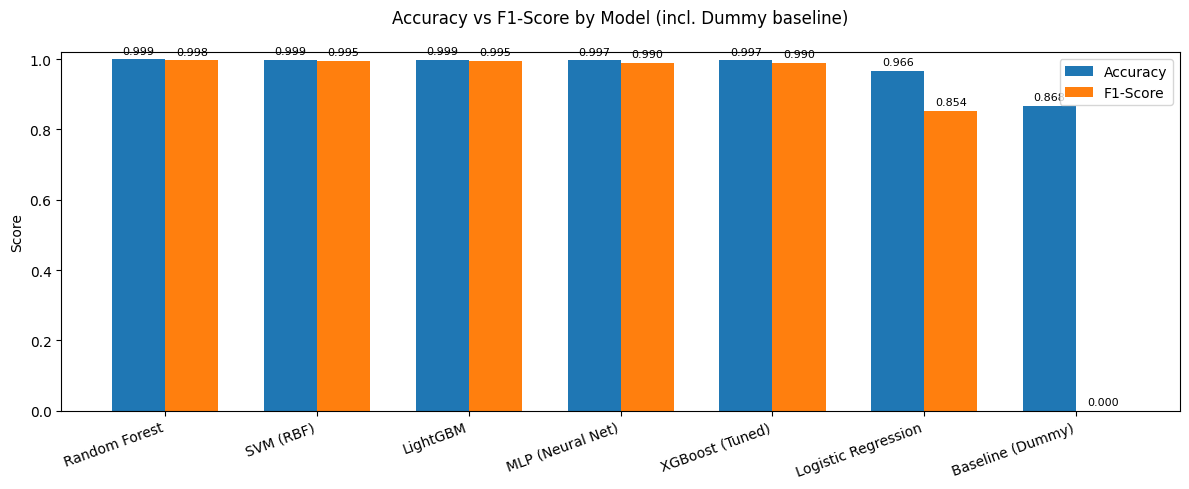

In [ ]:
# ============================================
# Side-by-side bars: Accuracy and F1-Score (incl. Dummy baseline)
# ============================================
import numpy as np
import matplotlib.pyplot as plt

df = metrics_df_with_baseline.copy()  # reuse the DataFrame from the previous cell

labels = df["Model"].values
accs   = df["Accuracy"].values
f1s    = df["F1-Score"].values

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - w/2, accs, width=w, label="Accuracy")
plt.bar(x + w/2, f1s,  width=w, label="F1-Score")

plt.xticks(x, labels, rotation=20, ha="right")
plt.ylim(0.0, 1.02)
plt.ylabel("Score")
plt.title("Accuracy vs F1-Score by Model (incl. Dummy baseline)\n")
plt.legend()

# annotate bars
for i, (a, f) in enumerate(zip(accs, f1s)):
    plt.text(i - w/2, a + 0.01, f"{a:.3f}", ha="center", va="bottom", fontsize=8)
    plt.text(i + w/2, f + 0.01, f"{f:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("accuracy_f1_with_baseline.png", dpi=300, bbox_inches="tight")
plt.show()


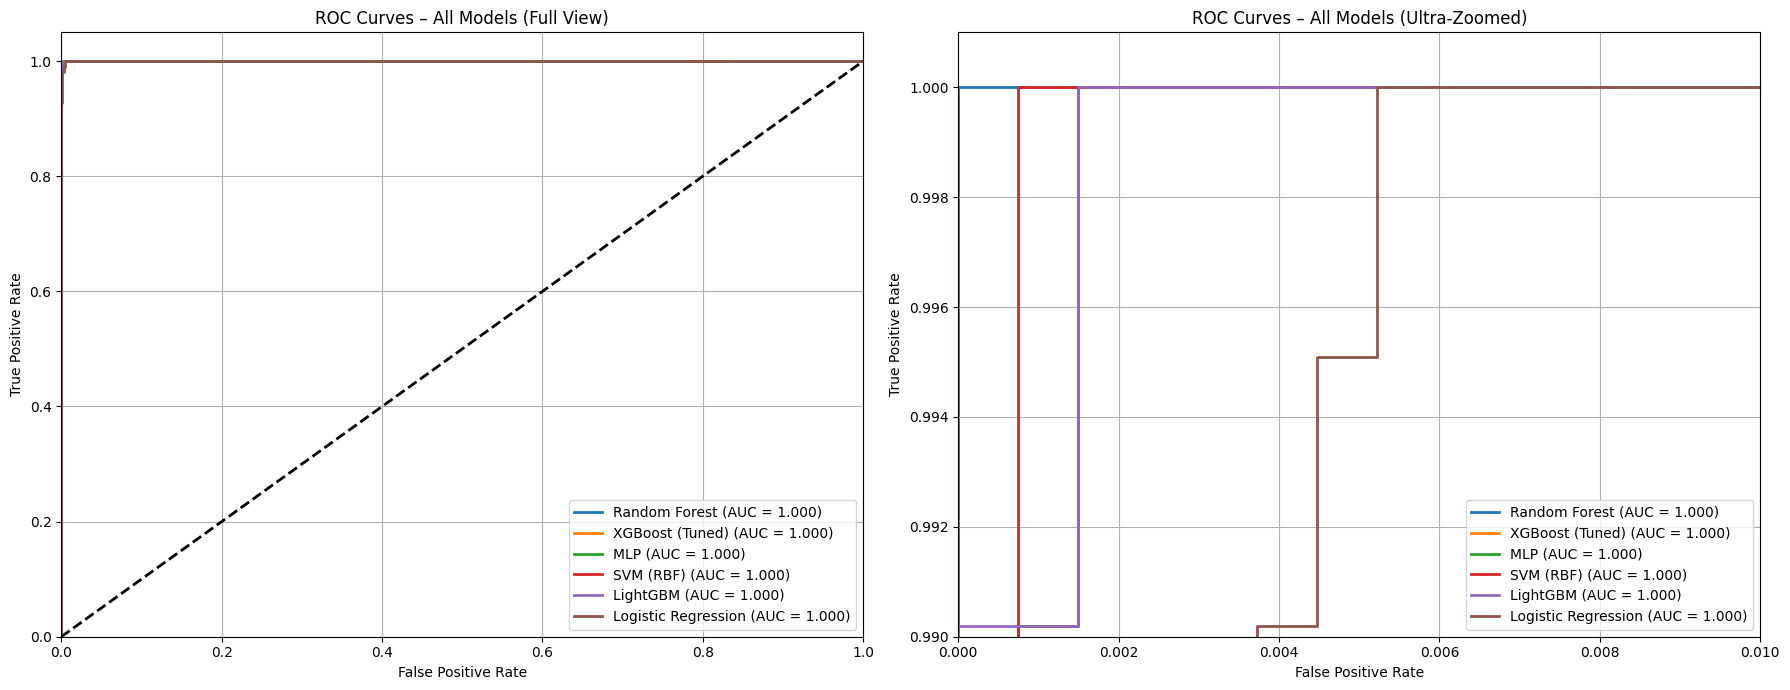

In [ ]:
# ============================================
# ROC Curves – Full + Ultra-Zoomed (final 6 models)
# ============================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Use your actual fitted model variables (final list – no XGB default)
models_dict = {
    "Random Forest": rf_model,
    "XGBoost (Tuned)": xgb_best,
    "MLP": mlp_pipe,
    "SVM (RBF)": svm_best,
    "LightGBM": lgbm_model,
    "Logistic Regression": logreg_model
}

# -------- build data once so both subplots use identical curves --------
roc_data = {}
for name, model in models_dict.items():
    # score = P(class=1); for SVM without predict_proba use decision_function
    y_score = (model.predict_proba(X_test)[:, 1]
               if hasattr(model, "predict_proba")
               else model.decision_function(X_test))
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, roc_auc)

# -------- side-by-side figure --------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full view
for name, (fpr, tpr, roc_auc) in roc_data.items():
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[0].set_xlim(0.0, 1.0)
axes[0].set_ylim(0.0, 1.05)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves – All Models (Full View)")
axes[0].legend(loc="lower right", fontsize=10)
axes[0].grid(True)

# Ultra-zoomed view (same curves, tight limits)
for name, (fpr, tpr, roc_auc) in roc_data.items():
    axes[1].plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_xlim(0.0, 0.01)   # ← horizontal ultra-zoom
axes[1].set_ylim(0.99, 1.001) # ← vertical ultra-zoom
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves – All Models (Ultra-Zoomed)")
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Optional: save images for CW3 report
fig.savefig("roc_curves_full_and_zoomed.png", dpi=300, bbox_inches="tight")


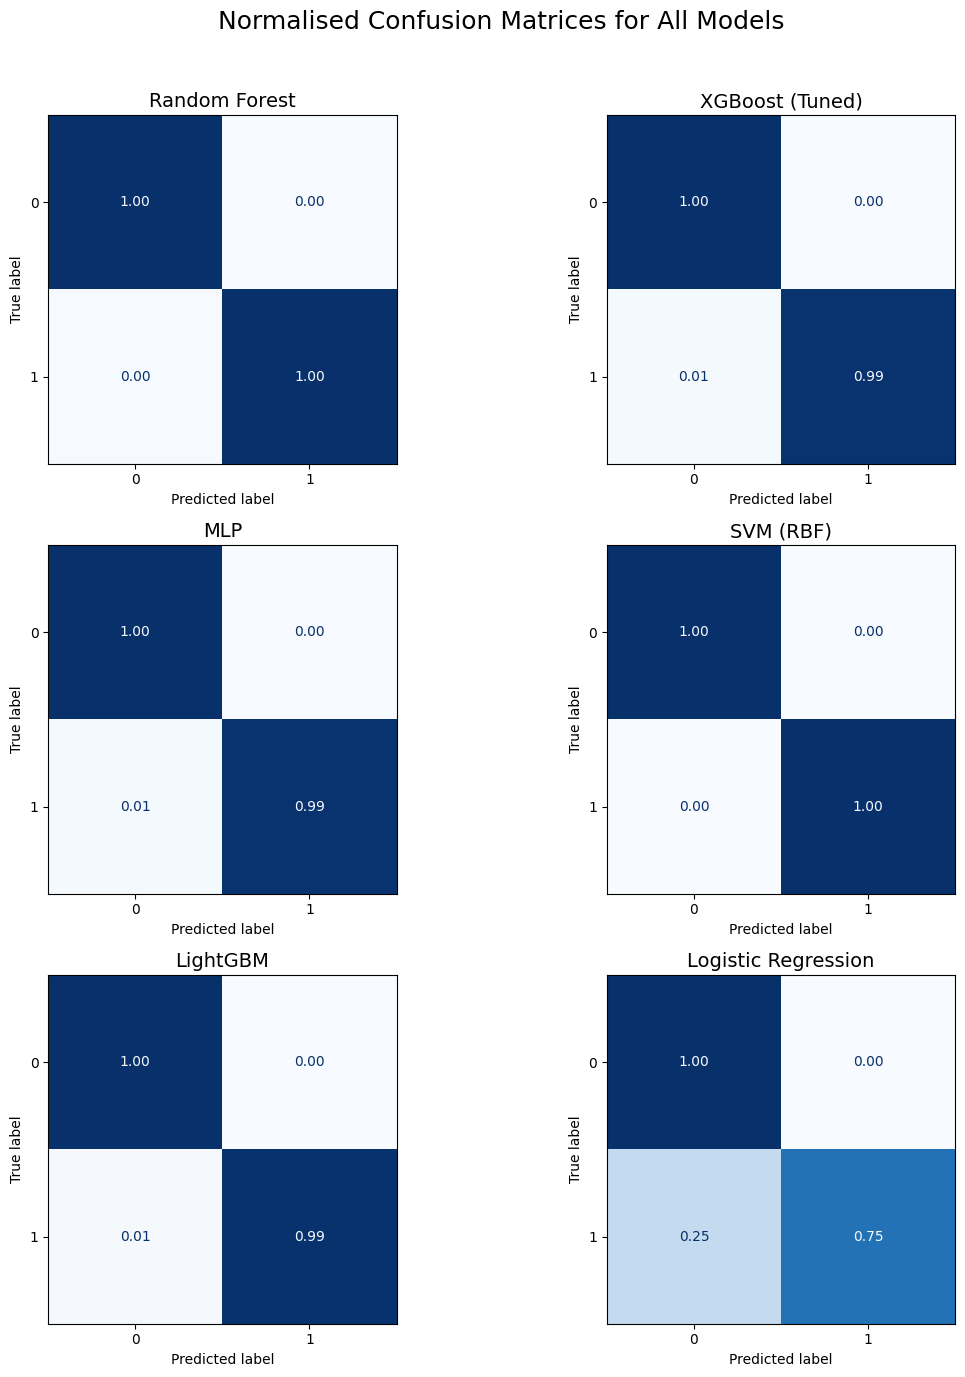

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Models to include (excluding XGBoost Default)
models_dict_filtered = {
    "Random Forest": rf_model,
    "XGBoost (Tuned)": xgb_best,
    "MLP": mlp_pipe,
    "SVM (RBF)": svm_best,
    "LightGBM": lgbm_model,
    "Logistic Regression": logreg_model
}

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models_dict_filtered.items()):
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        normalize='true',  # Normalised to show %
        cmap='Blues',
        ax=ax,
        values_format=".2f",  # Show 2 decimal places
        colorbar=False
    )
    ax.set_title(name, fontsize=14)

plt.suptitle("Normalised Confusion Matrices for All Models", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


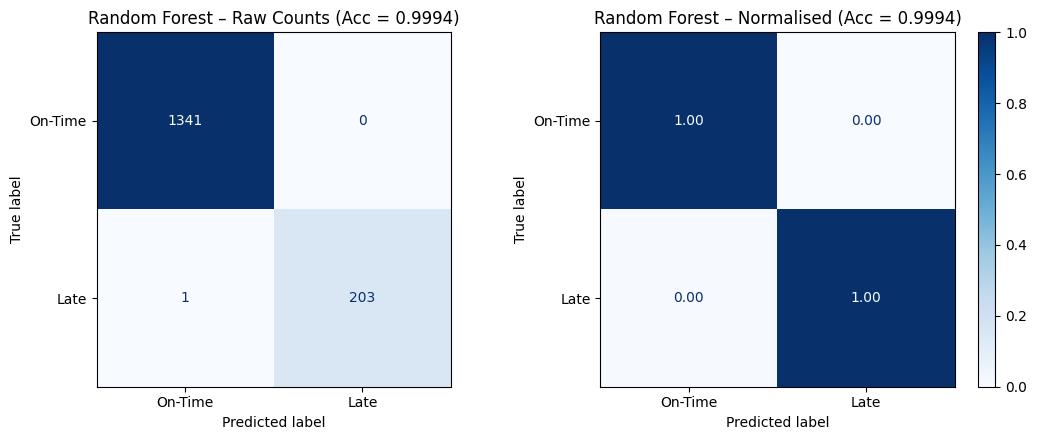

In [ ]:
# ============================================
# Best Model (Random Forest): Raw vs Normalised Confusion Matrices
# High-res figure for CW3 report
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Predictions from the already-fitted Random Forest model
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

# Raw counts & normalized matrices
cm_raw  = confusion_matrix(y_test, rf_preds)
cm_norm = confusion_matrix(y_test, rf_preds, normalize="true")

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Raw counts
disp_raw = ConfusionMatrixDisplay(confusion_matrix=cm_raw, display_labels=["On-Time", "Late"])
disp_raw.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title(f"Random Forest – Raw Counts (Acc = {rf_acc:.4f})")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

# Normalised
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["On-Time", "Late"])
disp_norm.plot(ax=axes[1], cmap="Blues", colorbar=True, values_format=".2f")
axes[1].set_title(f"Random Forest – Normalised (Acc = {rf_acc:.4f})")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

plt.tight_layout()
plt.savefig("best_model_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()


,feature,importance
0,distance_to_stop_km,0.966348
1,longitude,0.021291
2,latitude,0.011445
3,line_ref_encoded,0.000915


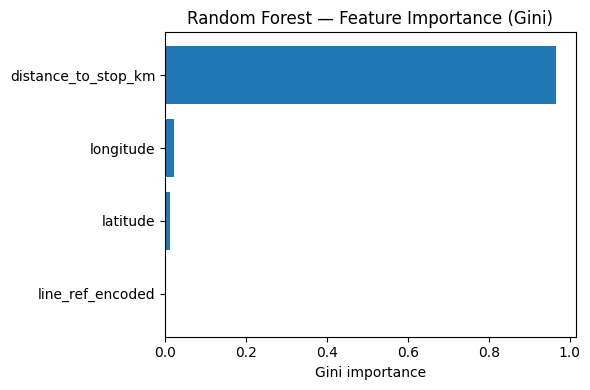

In [ ]:
# ============================================
# Random Forest — Feature Importance (Gini)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If your trained model is named differently, change rf_model below
best_rf = rf_model

# Make a nicely sorted table
fi = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(fi)

# Plot
plt.figure(figsize=(6,4))
plt.barh(fi["feature"][::-1], fi["importance"][::-1])
plt.xlabel("Gini importance")
plt.title("Random Forest — Feature Importance (Gini)")
plt.tight_layout()
plt.savefig("rf_feature_importance_gini.png", dpi=300, bbox_inches="tight")
plt.show()

# (optional) save the table
fi.to_csv("rf_feature_importance_gini.csv", index=False)


,feature,mean_importance,std_importance
0,distance_to_stop_km,0.226882,0.00689
1,latitude,0.000000,0.00000
2,longitude,0.000000,0.00000
3,line_ref_encoded,0.000000,0.00000


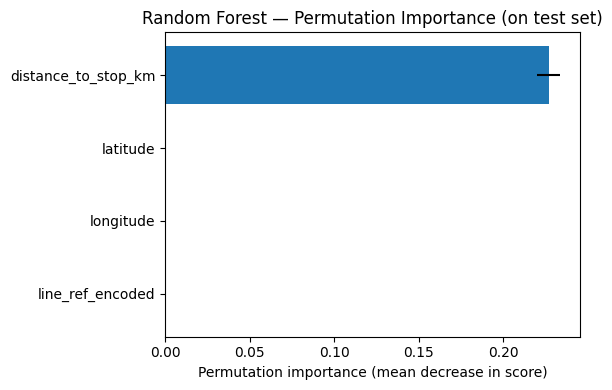

In [ ]:
# Permutation importance (serial to avoid BrokenProcessPool)
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_rf,                      # your fitted RandomForest
    X_test, y_test,
    n_repeats=30,
    random_state=42,
    n_jobs=1                      # <— run in-process
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean_importance": perm.importances_mean,
    "std_importance": perm.importances_std
}).sort_values("mean_importance", ascending=False).reset_index(drop=True)

display(perm_df)

plt.figure(figsize=(6,4))
plt.barh(perm_df["feature"][::-1], perm_df["mean_importance"][::-1],
         xerr=perm_df["std_importance"][::-1])
plt.xlabel("Permutation importance (mean decrease in score)")
plt.title("Random Forest — Permutation Importance (on test set)")
plt.tight_layout()
plt.savefig("rf_permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# ================================
# SHAP (old API) for Random Forest
# - Global bar (mean |SHAP|)
# - Beeswarm (direction + spread)
# - Export a table of mean |SHAP|
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Make sure we see plots nicely
plt.rcParams["figure.dpi"] = 110

# 1) Build explainer on the fitted best Random Forest
explainer = shap.TreeExplainer(best_rf)

# 2) Compute SHAP values on the test set
#    For classifiers, shap_values is a list [class0, class1]; we want the "positive" class.
shap_values = explainer.shap_values(X_test)
sv_pos = shap_values[1] if isinstance(shap_values, list) else shap_values   # (n_samples, n_features)

# 3) SHAP beeswarm (direction + distribution)
plt.figure(figsize=(7, 5))
shap.summary_plot(
    sv_pos,
    X_test,
    plot_type="dot",
    max_display=20,
    show=False
)
plt.title("Random Forest — SHAP Beeswarm (positive class)", pad=10)
plt.tight_layout()
plt.savefig("rf_shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.close()

# 4) SHAP bar (mean |SHAP| per feature)
plt.figure(figsize=(7, 5))
shap.summary_plot(
    sv_pos,
    X_test,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Random Forest — SHAP (mean |impact| on model output)", pad=10)
plt.tight_layout()
plt.savefig("rf_shap_bar.png", dpi=300, bbox_inches="tight")
plt.close()

# --- Robust export of mean |SHAP| table ---
# Force 1-D numpy array
mean_abs = np.asarray(np.abs(sv_pos).mean(axis=0)).ravel()

# Force plain Python list of feature names
features = list(X_test.columns)

# If (for any reason) lengths differ, align to the smaller length
n = min(len(features), len(mean_abs))
features = features[:n]
mean_abs = mean_abs[:n]

shap_table = (
    pd.DataFrame({"feature": features, "mean_abs_shap": mean_abs})
      .sort_values("mean_abs_shap", ascending=False)
      .reset_index(drop=True)
)

display(shap_table.head(10))

shap_table.to_csv("rf_shap_mean_abs.csv", index=False)
print("Saved: rf_shap_mean_abs.csv")

,feature,mean_abs_shap
0,line_ref_encoded,0.004552
1,distance_to_stop_km,0.004552
2,longitude,0.002706
3,latitude,0.002706


Saved: rf_shap_mean_abs.csv


<Figure size 770x550 with 0 Axes>

<Figure size 770x550 with 0 Axes>

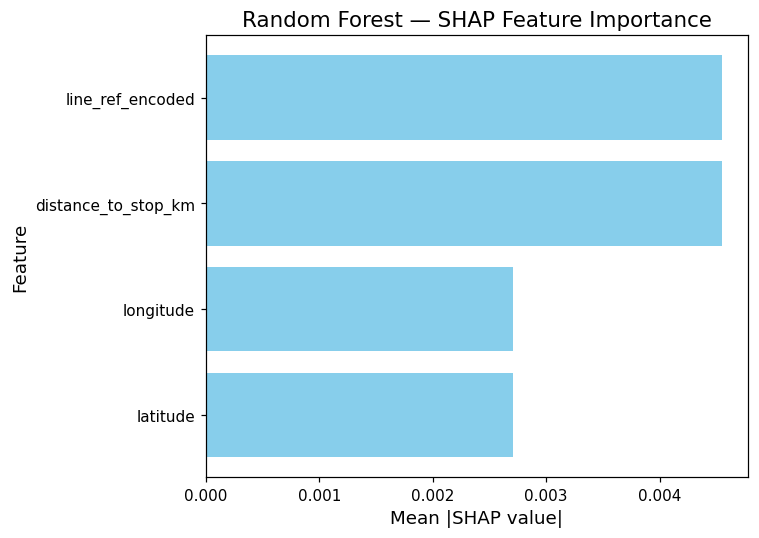

Saved: rf_shap_mean_abs.csv and rf_shap_mean_abs.png


In [ ]:
import matplotlib.pyplot as plt

# Sort by SHAP importance for cleaner plotting
shap_table_sorted = shap_table.sort_values("mean_abs_shap", ascending=True)

# Bar plot
plt.figure(figsize=(7,5))
plt.barh(shap_table_sorted["feature"], shap_table_sorted["mean_abs_shap"], color="skyblue")
plt.xlabel("Mean |SHAP value|", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Random Forest — SHAP Feature Importance", fontsize=14)
plt.tight_layout()

# Save the plot
plt.savefig("rf_shap_mean_abs.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

# Save table as CSV (already done, but keeping here for completeness)
shap_table.to_csv("rf_shap_mean_abs.csv", index=False)
print("Saved: rf_shap_mean_abs.csv and rf_shap_mean_abs.png")


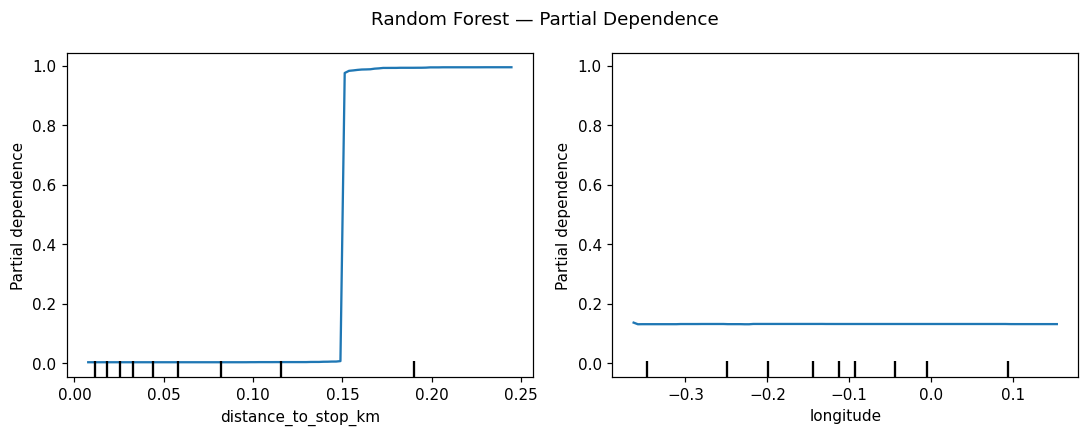

In [ ]:
# ============================================
# Random Forest — Partial Dependence (optional)
# ============================================

from sklearn.inspection import PartialDependenceDisplay

top_feats = fi["feature"].head(2).tolist()  # change number if you want more

fig, ax = plt.subplots(1, len(top_feats), figsize=(5*len(top_feats), 4))
PartialDependenceDisplay.from_estimator(best_rf, X_test, features=top_feats, ax=ax)
plt.suptitle("Random Forest — Partial Dependence")
plt.tight_layout()
plt.savefig("rf_partial_dependence.png", dpi=300, bbox_inches="tight")
plt.show()


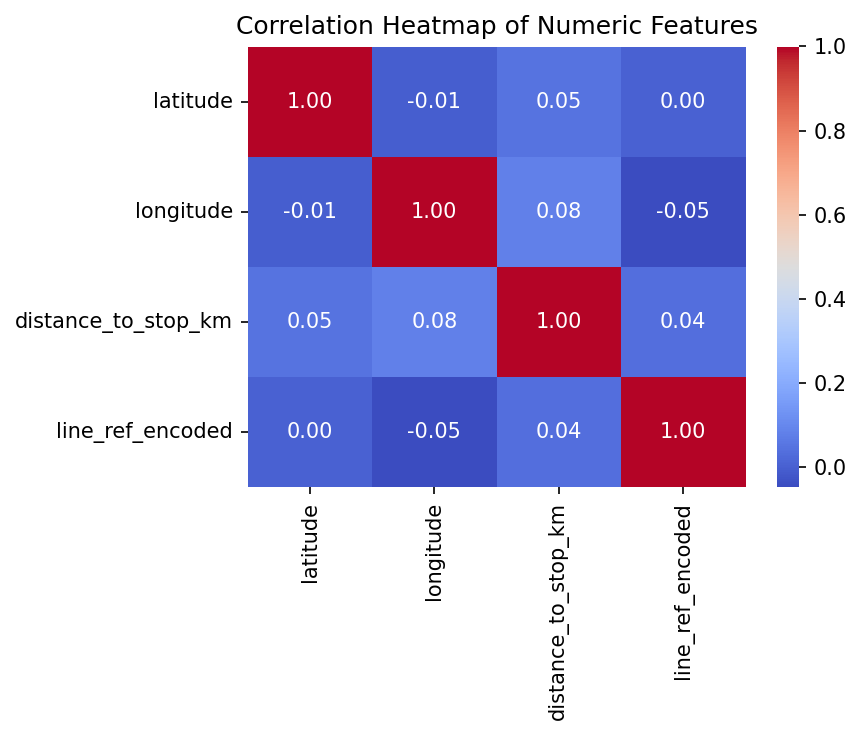

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5), dpi=150)
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features", fontsize=12)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()


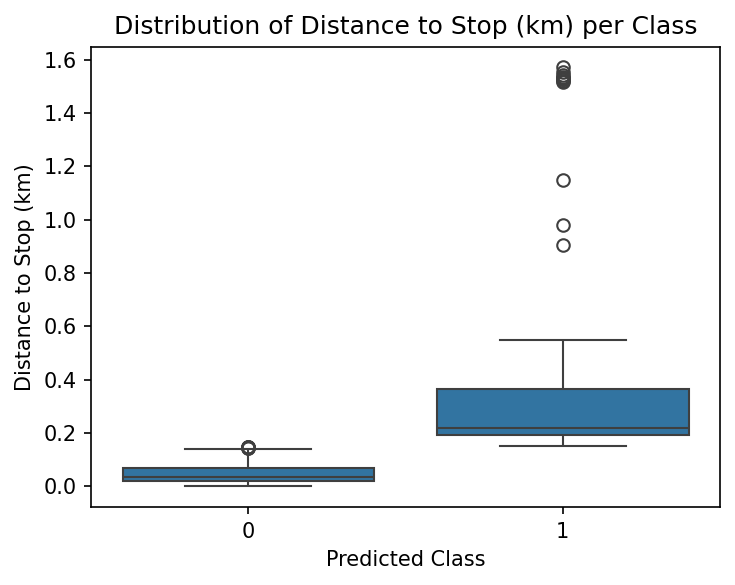

In [ ]:
plt.figure(figsize=(5, 4), dpi=150)
sns.boxplot(x=y_test, y=X_test['distance_to_stop_km'])
plt.title("Distribution of Distance to Stop (km) per Class", fontsize=12)
plt.xlabel("Predicted Class")
plt.ylabel("Distance to Stop (km)")
plt.tight_layout()
plt.savefig("boxplot_distance_class.png", dpi=300)
plt.show()


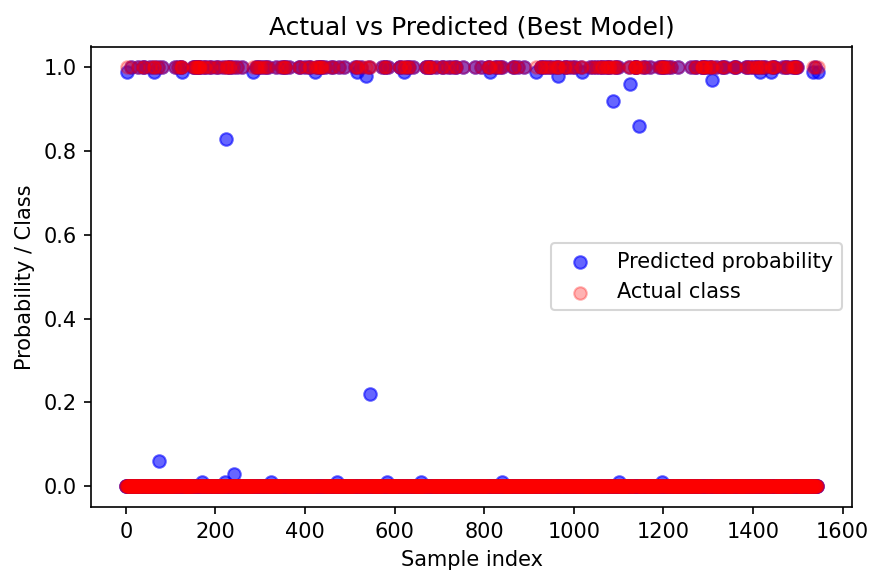

In [ ]:
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(6, 4), dpi=150)
plt.scatter(range(len(y_test)), y_pred_proba, color='blue', alpha=0.6, label='Predicted probability')
plt.scatter(range(len(y_test)), y_test, color='red', alpha=0.3, label='Actual class')
plt.title("Actual vs Predicted (Best Model)", fontsize=12)
plt.xlabel("Sample index")
plt.ylabel("Probability / Class")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=300)
plt.show()

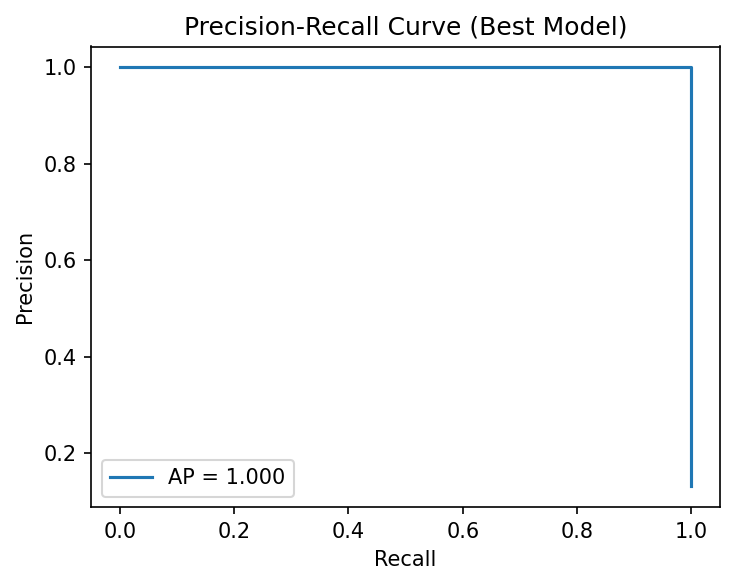

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
ap_score = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(5, 4), dpi=150)
plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Best Model)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("precision_recall_curve.png", dpi=300)
plt.show()

In [ ]:
matched_df['predicted_status_label'] = matched_df['predicted_status'].map({0: 'on_time', 1: 'late'})

matched_df.to_csv("bus_delay_predictions_labeled.csv", index=False)

print("Labeled prediction dataset saved as 'bus_delay_predictions_labeled.csv'")


In [ ]:
import matplotlib.pyplot as plt

pred_counts = matched_df['predicted_status'].value_counts().sort_index()
labels = ['On-Time', 'Late']

plt.figure(figsize=(6,4))
plt.bar(labels, pred_counts, color=['green', 'red'])
plt.title('Predicted Delay Status Distribution')
plt.ylabel('Number of Buses')
plt.xlabel('Status')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

matched_df['predicted_label'] = matched_df['predicted_status'].map({0: 'On-Time', 1: 'Late'})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=matched_df,
    x='longitude', y='latitude',
    hue='predicted_label',
    palette={'On-Time': 'green', 'Late': 'red'},
    alpha=0.7
)
plt.title('Bus Vehicle Locations Colored by Predicted Status')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import folium
from folium.plugins import MarkerCluster

london_coords = [51.5074, -0.1278]

bus_map = folium.Map(location=london_coords, zoom_start=11)
marker_cluster = MarkerCluster().add_to(bus_map)

for _, row in matched_df.iterrows():
    lat = row['latitude']
    lon = row['longitude']
    status = row['predicted_status']
    stop = row['closest_stop_name']

    color = 'green' if status == 0 else 'red'
    label = 'On-Time' if status == 0 else 'Late'

    popup = f"Bus: {row['vehicle_id']}<br>Line: {row['line_ref']}<br>Status: {label}<br>Stop: {stop}"

    folium.Marker(
        location=[lat, lon],
        popup=popup,
        icon=folium.Icon(color=color)
    ).add_to(marker_cluster)

bus_map


In [ ]:
bus_map.save('bus_delay_map.html')


In [ ]:
matched_df['aimed_departure_dt'] = pd.to_datetime(matched_df['aimed_departure'], errors='coerce')

In [ ]:
 import matplotlib.pyplot as plt

valid_df = matched_df.dropna(subset=['aimed_departure_dt'])

valid_df = valid_df.sort_values('aimed_departure_dt')

colors = valid_df['predicted_status'].map({0: 'green', 1: 'red'})

plt.figure(figsize=(12, 4))
plt.scatter(valid_df['aimed_departure_dt'], valid_df['predicted_status'], c=colors, alpha=0.5)

plt.yticks([0, 1], ['On-Time', 'Late'])
plt.xlabel("Aimed Departure Time")
plt.ylabel("Predicted Status")
plt.title("Timeline of Predicted Bus Delays")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import joblib

joblib.dump(xgb_best, "final_xgboost_model.pkl")

matched_df.to_csv("final_bus_delay_predictions.csv", index=False)

print("Final tuned model and predictions saved for report use")
